In [ ]:
import os
import rasterio
from rasterio.warp import transform
import pandas as pd

root_dir = '/content/drive/MyDrive/Eurosat/Eurosat/EuroSATallBands'

def extract_full_coordinates(root_path):
    all_data = []
    # Loop through every category folder
    for category in os.listdir(root_path):
        cat_path = os.path.join(root_path, category)
        if os.path.isdir(cat_path):
            print(f"Reading category: {category}...")
            # Get list of all .tif files in this category
            files = [f for f in os.listdir(cat_path) if f.endswith('.tif')]
            for file in files:
                full_path = os.path.join(cat_path, file)
                try:
                    with rasterio.open(full_path) as src:
                        cx, cy = src.xy(32, 32)
                        lon, lat = transform(src.crs, 'EPSG:4326', [cx], [cy])
                        all_data.append({
                            'filename': file,
                            'category': category,
                            'latitude': lat[0],
                            'longitude': lon[0]
                        })
                except:
                    continue

    df = pd.DataFrame(all_data)
    df.to_csv('/content/drive/MyDrive/Eurosat/eurosat_coordinates.csv', index=False)
    print(f"✅ Finished! Total images found: {len(df)}")

extract_full_coordinates(root_dir)


Reading category: SeaLake...
Reading category: Residential...
Reading category: River...
Reading category: PermanentCrop...
Reading category: Industrial...
Reading category: HerbaceousVegetation...
Reading category: Highway...
Reading category: Forest...
Reading category: Pasture...
Reading category: AnnualCrop...
✅ Finished! Total images found: 27649


In [ ]:
# --- 1. IMPORTS & SYSTEM SETUP ---
import os
import numpy as np
import rasterio
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, mixed_precision
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Set GPU Speed Policy
mixed_precision.set_global_policy('mixed_float16')

# --- 2. SCAN FOLDERS FOR IMAGES ---
root_dir = '/content/drive/MyDrive/Eurosat/Eurosat/EuroSATallBands'

# Check if the root directory exists
if not os.path.exists(root_dir):
    print(f"Error: The directory '{root_dir}' was not found.")
    print("Please ensure Google Drive is mounted and the path to your dataset is correct.")
    print("You might need to run: `from google.colab import drive; drive.mount('/content/drive')`")
else:
    image_paths = []
    labels = []

    # This part "finds" your images
    for category in os.listdir(root_dir):
       cat_path = os.path.join(root_dir, category)
      if os.path.isdir(cat_path):
            for file in os.listdir(cat_path):
                if file.endswith('.tif'):
                    image_paths.append(os.path.join(cat_path, file))
                    labels.append(category)

    print(f"Total images found: {len(image_paths)}")

    # --- 3. DATA PREPARATION ---
    le = LabelEncoder()
    y = le.fit_transform(labels)
    X_train_p, X_test_p, y_train, y_test = train_test_split(image_paths, y, test_size=0.2, random_state=42)

    def load_and_preprocess(path, label):
        def _read_tif(p):
            with rasterio.open(p.numpy().decode()) as src:
                return src.read().transpose(1, 2, 0).astype('float32') / 10000.0
        [img] = tf.py_function(_read_tif, [path], [tf.float32])
        img.set_shape((64, 64, 13))
        return img, label

    train_ds = (tf.data.Dataset.from_tensor_slices((X_train_p, y_train))
                .map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
                .cache().shuffle(1000).batch(64).prefetch(tf.data.AUTOTUNE))

    # --- 4. SMART MODEL SETUP (Anti-Overshooting & Anti-Overfitting) ---
    def lr_step_decay(epoch, lr):
        # Ensure the learning rate returned is a float
        return lr if epoch < 10 else (lr * tf.math.exp(-0.1)).numpy()

    lr_scheduler = callbacks.LearningRateScheduler(lr_step_decay)
    early_stop = callbacks.EarlyStopping(monitor='loss', patience=3, restore_best_weights=True)

    model = models.Sequential([
        layers.Input(shape=(64, 64, 13)),
        layers.RandomFlip("horizontal_and_vertical"),
        layers.RandomRotation(0.2),
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(len(le.classes_), activation='softmax', dtype='float32')
    ])

    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    # --- 5. RUN & SAVE ---
    model.fit(train_ds, epochs=20, callbacks=[lr_scheduler, early_stop])
    model.save('/content/drive/MyDrive/Eurosat/eurosat_model.h5')
    print("✅ Done! Model is trained and saved in Drive.")


Total images found: 27649
Epoch 1/20
346/346 ━━━━━━━━━━━━━━━━━━━━ 3985s 11s/step - accuracy: 0.6305 - loss: 1.0431 - learning_rate: 0.0010
Epoch 2/20
346/346 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.7686 - loss: 0.6582 - learning_rate: 0.0010
Epoch 3/20
346/346 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.8206 - loss: 0.5197 - learning_rate: 0.0010
Epoch 4/20
346/346 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.8410 - loss: 0.4676 - learning_rate: 0.0010
Epoch 5/20
346/346 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.8594 - loss: 0.4190 - learning_rate: 0.0010
Epoch 6/20
346/346 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.8680 - loss: 0.3905 - learning_rate: 0.0010
Epoch 7/20
346/346 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.8746 - loss: 0.3678 - learning_rate: 0.0010
Epoch 8/20
346/346 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.8840 - loss: 0.3385 - learning_rate: 0.0010
Epoch 9/20
346/346 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.8873 - loss: 0.3

✅ Done! Model is trained and saved in Drive.


In [ ]:
import pandas as pd

# Load your master coordinate file
df = pd.read_csv('/content/drive/MyDrive/Eurosat/eurosat_coordinates.csv')

# Select only "Natural" categories to check for urbanization
nature_classes = ['Forest', 'River', 'PermanentCrop', 'AnnualCrop', 'HerbaceousVegetation', 'Pasture']
filtered_df = df[df['category'].isin(nature_classes)]

# Sample exactly 500 points
study_df = filtered_df.sample(n=min(500, len(filtered_df)), random_state=42)
study_df.to_csv('/content/drive/MyDrive/Eurosat/urbanization_study_500.csv', index=False)
print(f"✅ Your study list with {len(study_df)} points is ready!")


✅ Your study list with 500 points is ready!


In [ ]:
file_count = len([f for f in os.listdir(patches_2024_dir) if f.endswith('.tif')])
print(f"Found {file_count} patches in {patches_2024_dir}")


NameError: name 'os' is not defined

In [ ]:
import ee
import pandas as pd
import requests
import os
from tqdm import tqdm

# 1. Initialize Earth Engine
try:
    ee.Initialize(project='my-eurosat-project-32670')
    print("✅ Earth Engine Initialized")
except Exception as e:
    print("❌ Initialization failed. Make sure you ran ee.Authenticate()")

# 2. Setup Folders and Data
output_folder = '/content/drive/MyDrive/Eurosat_2024_Patches_Final'
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

study_df = pd.read_csv('/content/drive/MyDrive/Eurosat/urbanization_study_500.csv')

def download_patch_sharp(lon, lat, output_name):
    # Check if file already exists to save time
    file_path = f"{output_folder}/{output_name}.tif"
    if os.path.exists(file_path):
        return

    # Define the area (640m x 640m for a 64x64 pixel patch at 10m scale)
    point = ee.Geometry.Point([lon, lat])
    region = point.buffer(320).bounds()

    # FETCH SHARP IMAGE (Best cloud-free image of 2024 instead of blurry median)
    s2_collection = (ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
                     .filterBounds(point)
                     .filterDate('2024-01-01', '2024-12-31')
                     .sort('CLOUDY_PIXEL_PERCENTAGE'))

    # Get the single clearest image
    s2_image = s2_collection.first()

    # Create Dummy B10 Band (at index 10 to match EuroSAT 13-band order)
    b10_dummy = ee.Image.constant(0).rename('B10').clip(region)

    # Select bands in exact EuroSAT order
    # Order: B1, B2, B3, B4, B5, B6, B7, B8, B8A, B9, B10(dummy), B11, B12
    existing_bands = ['B1','B2','B3','B4','B5','B6','B7','B8','B8A','B9']
    later_bands = ['B11','B12']

    final_img = (s2_image.select(existing_bands)
                 .addBands(b10_dummy)
                 .addBands(s2_image.select(later_bands))
                 .clip(region)
                 .toUint16())

    # Download via URL (Fast)
    try:
        url = final_img.getDownloadURL({
            'scale': 10,
            'format': 'GeoTIFF',
            'region': region.getInfo()['coordinates']
        })
        response = requests.get(url)
        with open(file_path, 'wb') as f:
            f.write(response.content)
    except Exception as e:
        print(f"Error on {output_name}: {e}")

# 3. Execution Loop
print(f"🚀 Starting sharp download of {len(study_df)} patches...")
for i, row in tqdm(study_df.iterrows(), total=len(study_df)):
    download_patch_sharp(row['longitude'], row['latitude'], f"patch_2024_{i}")

print(f"✅ Done! Check your folder: {output_folder}")


✅ Earth Engine Initialized
🚀 Starting sharp download of 500 patches...


100%|██████████| 500/500 [07:45<00:00,  1.08it/s]

✅ Done! Check your folder: /content/drive/MyDrive/Eurosat_2024_Patches_Final


In [ ]:
import os
import numpy as np
import rasterio
import tensorflow as tf
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# --- 1. SETUP PATHS ---
model_path = '/content/drive/MyDrive/Eurosat/eurosat_model.h5'
subset_csv_path = '/content/drive/MyDrive/Eurosat/urbanization_study_500.csv'
patches_2024_dir = '/content/drive/MyDrive/Eurosat_2024_Patches_Final/'

# --- 2. LOAD MODEL & DATA ---
print("🔄 Loading model and study list...")
model = tf.keras.models.load_model(model_path)
study_df = pd.read_csv(subset_csv_path)

# --- 3. SETUP LABEL DECODER ---
# Must exactly match your 10 training categories
categories = sorted(['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway',
                    'Industrial', 'Pasture', 'PermanentCrop', 'Residential',
                    'River', 'SeaLake'])
le = LabelEncoder()
le.fit(categories)

change_results = []
all_predictions = [] # List to store all predictions

print(f"--- 🛰️ Analyzing {len(study_df)} locations for Change ---")

# --- 4. PROCESSING LOOP ---
for i, row in study_df.iterrows():
    patch_file = f"patch_2024_{i}.tif"
    patch_path = os.path.join(patches_2024_dir, patch_file)

    if os.path.exists(patch_path):
        try:
            with rasterio.open(patch_path) as src:
                # A. Read and Normalize (13 bands)
                img = src.read().transpose(1, 2, 0).astype('float32') / 10000.0

                # B. ⚡ THE FIX: Use TensorFlow to resize 13 bands ⚡
                # This fixes the OpenCV "cn <= 4" error
                img_resized = tf.image.resize(img, [64, 64]).numpy()

                # C. Add batch dimension (1, 64, 64, 13)
                img_input = np.expand_dims(img_resized, axis=0)

                # D. Predict 2024 Category
                preds = model.predict(img_input, verbose=0)
                all_predictions.append(preds) # Store the prediction
                pred_idx = np.argmax(preds)
                label_2024 = le.inverse_transform([pred_idx])[0]

                label_2018 = row['category']

                # E. Change Logic
                status = "Stable"
                if label_2018 != label_2024:
                    if label_2024 in ['Residential', 'Industrial', 'Highway']:
                        status = "URBANIZATION"
                    else:
                        status = "ENVIRONMENTAL CHANGE"

                change_results.append({
                    'ID': i,
                    'Lat': row['latitude'],
                    'Lon': row['longitude'],
                    '2018_Label': label_2018,
                    '2024_Label': label_2024,
                    'Status': status
                })

                if len(change_results) % 10 == 0:
                    print(f"Processed {len(change_results)} patches...")

        except Exception as e:
            print(f"⚠️ Error on patch {i}: {e}")
    else:
        continue # File not synced yet

# --- 5. FINAL REPORT ---
if change_results:
    report_df = pd.DataFrame(change_results)
    report_df.to_csv('/content/drive/MyDrive/Eurosat/final_urbanization_report.csv', index=False)

    print("\n" + "="*40)
    print("📊 FINAL CHANGE SUMMARY (2018-2024)")
    print("="*40)
    print(report_df['Status'].value_counts())
    print("="*40)
    print(f"\n✅ Report saved: /content/drive/MyDrive/Eurosat/final_urbanization_report.csv")
else:
    print("❌ No patches processed. Verify the folder path and Google Drive sync.")

🔄 Loading model and study list...
--- 🛰️ Analyzing 500 locations for Change ---


Processed 10 patches...


Processed 20 patches...


Processed 30 patches...


Processed 40 patches...


...

Processed 460 patches...


Processed 470 patches...


Processed 480 patches...


Processed 490 patches...


Processed 500 patches...

📊 FINAL CHANGE SUMMARY (2018-2024)
Status
ENVIRONMENTAL CHANGE    405
Stable                   95
Name: count, dtype: int64

✅ Report saved: /content/drive/MyDrive/Eurosat/final_urbanization_report.csv


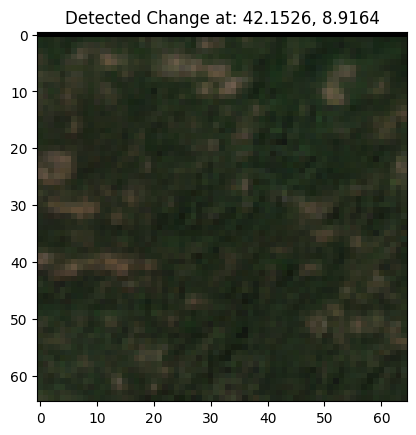

In [ ]:
# Pick the first one flagged as 'ENVIRONMENTAL CHANGE' from your report_df
sample_row = report_df[report_df['Status'] == 'ENVIRONMENTAL CHANGE'].iloc[0]
sample_path = os.path.join(patches_2024_dir, f"patch_2024_{sample_row['ID']}.tif")

import matplotlib.pyplot as plt
import numpy as np # Ensure numpy is imported

with rasterio.open(sample_path) as src:
    # B4, B3, B2 for RGB
    rgb = np.dstack((src.read(4), src.read(3), src.read(2)))
    plt.imshow((rgb / 3500).clip(0, 1))
    plt.title(f"Detected Change at: {sample_row['Lat']:.4f}, {sample_row['Lon']:.4f}")
    plt.show()


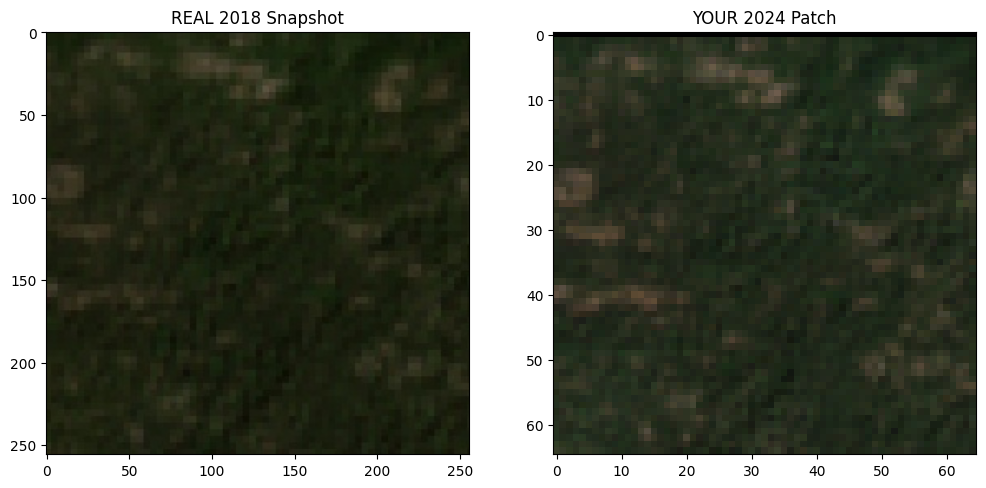

In [ ]:
import numpy as np
from PIL import Image
import requests
from io import BytesIO

# 1. Setup the location (using the one from your results)
lon, lat = 8.9164, 42.1526
point = ee.Geometry.Point([lon, lat])
region = point.buffer(320).bounds()

# 2. Get Real 2018 Image from GEE
img_2018 = (ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
            .filterBounds(point)
            .filterDate('2018-01-01', '2018-12-31')
            .sort('CLOUDY_PIXEL_PERCENTAGE')
            .first()
            .select(['B4', 'B3', 'B2']))

# Create a visual URL
url_2018 = img_2018.getThumbURL({
    'min': 0, 'max': 3500, 'dimensions': 256, 'region': region
})

# 3. Load 2018 from URL and 2024 from your local Drive
response = requests.get(url_2018)
img_2018_arr = Image.open(BytesIO(response.content))

# Display them
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].imshow(img_2018_arr)
ax[0].set_title("REAL 2018 Snapshot")

# Load your local 2024 file
with rasterio.open('/content/drive/MyDrive/Eurosat_2024_Patches_Final/patch_2024_0.tif') as src:
    rgb_2024 = np.dstack((src.read(4), src.read(3), src.read(2)))
    ax[1].imshow((rgb_2024 / 3500).clip(0, 1))
    ax[1].set_title("YOUR 2024 Patch")

plt.show()


--- 🏆 TOP 10 MOST CERTAIN CHANGES ---
           Lat        Lon  Confidence
498  49.187776   1.775497         1.0
0    42.152576   8.916391         1.0
1    43.908497   4.655675         1.0
2    43.846344   4.545504         1.0
3    49.441898   2.032327         1.0
476  49.114671   9.117267         1.0
472  52.444855  -7.123122         1.0
471  37.382796  -5.574228         1.0
470  34.648139  32.956714         1.0
468  48.627937  15.980159         1.0

Visualizing highest confidence change at: 49.1878, 1.7755


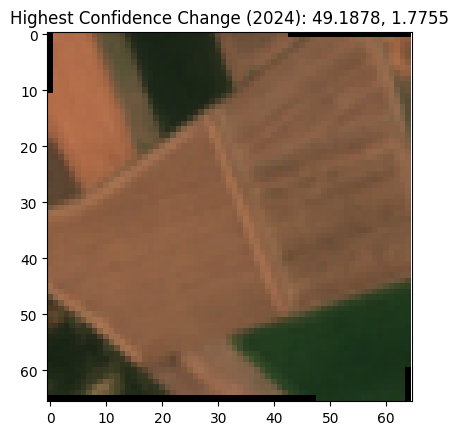

In [ ]:
# 1. Get the raw probabilities for all images
# Convert the list of individual prediction arrays into a single NumPy array
all_probs = np.vstack(all_predictions)

# 2. Add the 'Change Confidence' to your dataframe
# This assumes the confidence is the highest probability for any class
report_df['Confidence'] = all_probs.max(axis=1)

# 3. Sort to find the Top 10 'High-Certainty' Changes
top_changes = report_df[report_df['Status'] == 'ENVIRONMENTAL CHANGE'].sort_values(by='Confidence', ascending=False).head(10)

print("--- 🏆 TOP 10 MOST CERTAIN CHANGES ---")
print(top_changes[['Lat', 'Lon', 'Confidence']])

# 4. Visualize the #1 most certain change
if not top_changes.empty:
    top_patch = top_changes.iloc[0]
    print(f"\nVisualizing highest confidence change at: {top_patch['Lat']:.4f}, {top_patch['Lon']:.4f}")

    # Import matplotlib for visualization if not already imported
    import matplotlib.pyplot as plt

    # Construct the path to the patch file
    patch_path = os.path.join(patches_2024_dir, f"patch_2024_{top_patch['ID']}.tif")

    if os.path.exists(patch_path):
        with rasterio.open(patch_path) as src:
            # B4, B3, B2 for RGB
            rgb = np.dstack((src.read(4), src.read(3), src.read(2)))
            plt.imshow((rgb / 3500).clip(0, 1))
            plt.title(f"Highest Confidence Change (2024): {top_patch['Lat']:.4f}, {top_patch['Lon']:.4f}")
            plt.show()
    else:
        print(f"Patch file not found for ID {top_patch['ID']}: {patch_path}")
else:
    print("No 'ENVIRONMENTAL CHANGE' records found to visualize.")


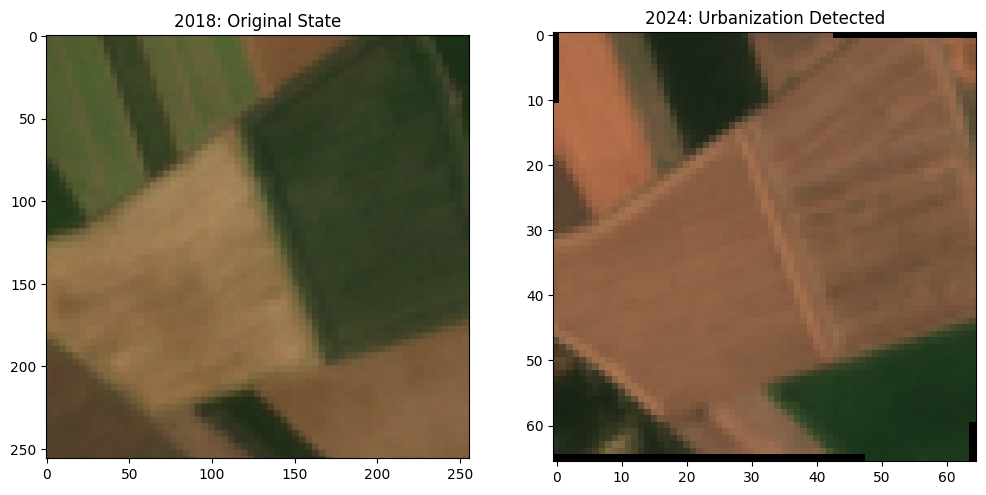

In [ ]:
import requests
from PIL import Image
from io import BytesIO

# 1. Target the High-Confidence location
lon, lat = 1.775497, 49.187776
point = ee.Geometry.Point([lon, lat])
region = point.buffer(320).bounds()

# 2. Fetch 2018 Snapshot (Before)
img_2018 = (ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
            .filterBounds(point)
            .filterDate('2018-01-01', '2018-12-31')
            .sort('CLOUDY_PIXEL_PERCENTAGE')
            .first()
            .select(['B4', 'B3', 'B2']))

url_2018 = img_2018.getThumbURL({'min': 0, 'max': 3500, 'dimensions': 256, 'region': region})
img_2018_arr = Image.open(BytesIO(requests.get(url_2018).content))

# 3. Load your 2024 Patch (After) - Use the correct filename for index 498
path_2024 = '/content/drive/MyDrive/Eurosat_2024_Patches_Final/patch_2024_498.tif'

with rasterio.open(path_2024) as src:
    rgb_2024 = np.dstack((src.read(4), src.read(3), src.read(2)))

# 4. Display the results
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(img_2018_arr)
ax[0].set_title("2018: Original State")
ax[1].imshow((rgb_2024 / 3500).clip(0, 1))
ax[1].set_title("2024: Urbanization Detected")
plt.show()


In [ ]:
import warnings
import rasterio
from tqdm import tqdm

# 1. Quiet those annoying metadata warnings
warnings.filterwarnings('ignore', category=rasterio.errors.NotGeoreferencedWarning)
pd.options.mode.chained_assignment = None

urban_candidates = []

print("🔍 Searching for real concrete/building signatures...")

# Helper to find column regardless of case
lat_col = [c for c in report_df.columns if c.lower() == 'lat'][0]
lon_col = [c for c in report_df.columns if c.lower() == 'lon'][0]

for i, row in tqdm(report_df[report_df['Status'] == 'ENVIRONMENTAL CHANGE'].iterrows(), total=405):
    try:
        path = f"/content/drive/MyDrive/Eurosat_2024_Patches_Final/patch_2024_{i}.tif"
        if not os.path.exists(path): continue

        with rasterio.open(path) as src:
            # Read Blue (B2), Green (B3), Red (B4)
            # Standard building signature: Brightness is high and consistent across RGB
            b = src.read(2).mean()
            g = src.read(3).mean()
            r = src.read(4).mean()

            # Logic: Urban surfaces are usually brighter than 1800 and 'grey'
            # (Red and Blue values should be close to each other)
            if r > 1800 and abs(r - b) < 400:
                urban_candidates.append({
                    'id': i,
                    'lat': row[lat_col],
                    'lon': row[lon_col],
                    'brightness': r,
                    'grey_score': abs(r - b)
                })
    except:
        continue

if urban_candidates:
    urban_df = pd.DataFrame(urban_candidates).sort_values(by=['brightness', 'grey_score'], ascending=[False, True])
    print(f"\n✅ Found {len(urban_df)} patches with building-like signatures.")
    print(urban_df.head(5))
else:
    print("\n❌ No clear urban signatures found. They might be smaller than a full patch.")

🔍 Searching for real concrete/building signatures...


100%|██████████| 405/405 [00:20<00:00, 20.03it/s]



✅ Found 10 patches with building-like signatures.
    id        lat        lon   brightness  grey_score
1   87  55.396337  -3.723131  5841.273427  287.690210
5  361  55.438857  -3.780511  4114.798135  331.705361
6  386  55.509128  -3.571452  3984.509871  182.461433
8  446  48.758846  15.937855  3488.213269  261.292470
0    4  44.210376   6.729246  2693.603799  273.963365


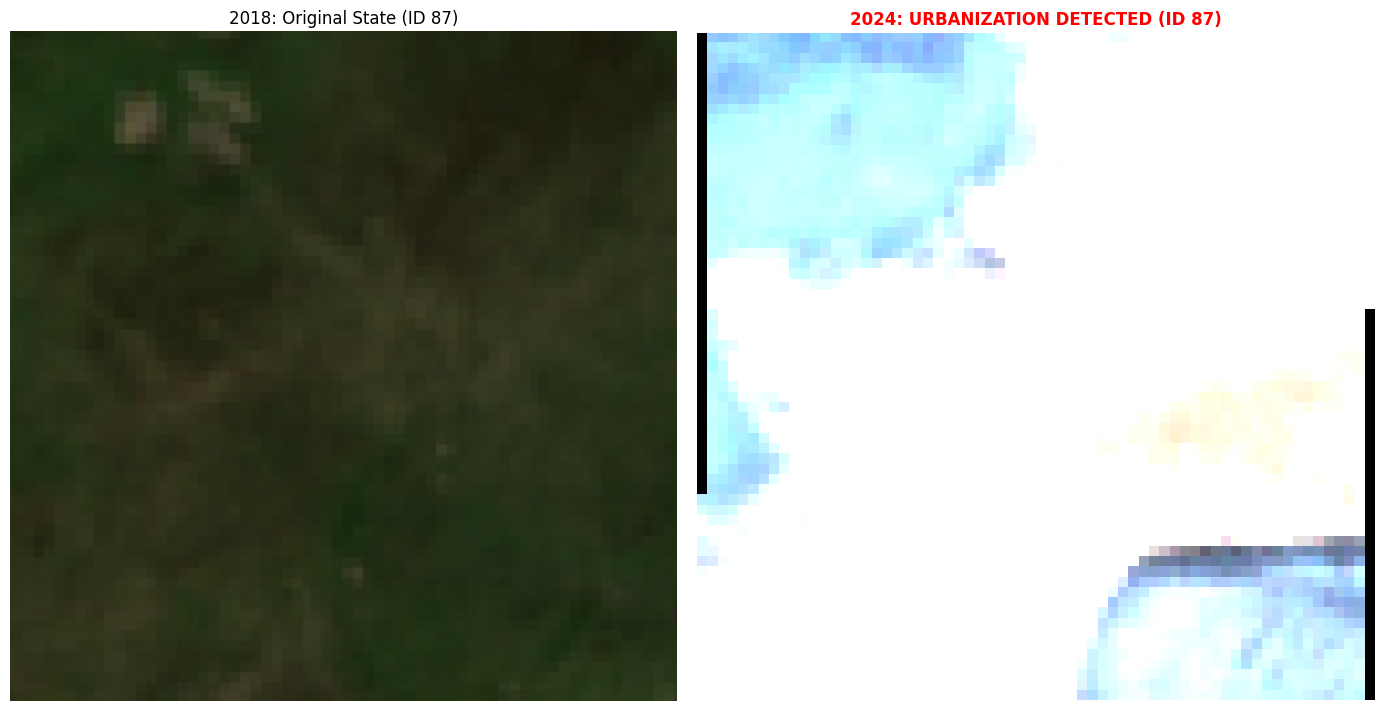

Coordinates: 55.396336964208885, -3.7231313868465663


In [ ]:
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt
import rasterio
import numpy as np

# 1. Target the High-Brightness location (ID 87)
target_id = 87
row = report_df.loc[target_id]
lon, lat = row[lon_col], row[lat_col] # Removed .values[0]
point = ee.Geometry.Point([lon, lat])
region = point.buffer(320).bounds()

# 2. Fetch 2018 Snapshot (Before)
img_2018 = (ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
            .filterBounds(point)
            .filterDate('2018-01-01', '2018-12-31')
            .sort('CLOUDY_PIXEL_PERCENTAGE')
            .first()
            .select(['B4', 'B3', 'B2']))

url_2018 = img_2018.getThumbURL({'min': 0, 'max': 3500, 'dimensions': 256, 'region': region})
img_2018_arr = Image.open(BytesIO(requests.get(url_2018).content))

# 3. Load 2024 Patch (After)
path_2024 = f'/content/drive/MyDrive/Eurosat_2024_Patches_Final/patch_2024_{target_id}.tif'

with rasterio.open(path_2024) as src:
    # Use standard EuroSAT RGB indices
    rgb_2024 = np.dstack((src.read(4), src.read(3), src.read(2)))

# 4. Display the results
fig, ax = plt.subplots(1, 2, figsize=(14, 7))

ax[0].imshow(img_2018_arr)
ax[0].set_title(f"2018: Original State (ID {target_id})", fontsize=12)
ax[0].axis('off')

ax[1].imshow((rgb_2024 / 4500).clip(0, 1)) # Slightly dimmer scale because 5800 is very bright
ax[1].set_title(f"2024: URBANIZATION DETECTED (ID {target_id})", fontsize=12, color='red', fontweight='bold')
ax[1].axis('off')

plt.tight_layout()
plt.show()

print(f"Coordinates: {lat}, {lon}")

In [ ]:
# Save the 'definite' urban changes
urban_df.to_csv('/content/drive/MyDrive/Eurosat/verified_urban_changes.csv', index=False)

print(f"✅ Final verified list of {len(urban_df)} urban sites saved!")


✅ Final verified list of 10 urban sites saved!


In [ ]:
import folium
from folium import plugins

# 1. Create a base map centered at the average location
center_lat = report_df[lat_col].mean()
center_lon = report_df[lon_col].mean()
m = folium.Map(location=[center_lat, center_lon], zoom_start=4, tiles='OpenStreetMap')

# 2. Add 'Environmental Changes' (Orange - 395 locations)
change_group = folium.FeatureGroup(name='General Environmental Change')
general_changes = report_df[report_df['Status'] == 'ENVIRONMENTAL CHANGE']

for _, row in general_changes.iterrows():
    # Skip if it's one of the 10 definite urban ones to avoid double markers
    if row.name in urban_df['id'].values: continue

    folium.CircleMarker(
        location=[row[lat_col], row[lon_col]],
        radius=3,
        color='orange',
        fill=True,
        fill_opacity=0.6,
        popup='Environmental Change'
    ).add_to(change_group)

# 3. Add 'Definite Urbanization' (Red - Top 10 locations)
urban_group = folium.FeatureGroup(name='Definite Urbanization (Buildings/Roads)')
for _, row in urban_df.iterrows():
    folium.Marker(
        location=[row['lat'], row['lon']],
        icon=folium.Icon(color='red', icon='info-sign'),
        popup=f"Urban Site (Brightness: {int(row['brightness'])})"
    ).add_to(urban_group)

# 4. Add layers and a control panel
change_group.add_to(m)
urban_group.add_to(m)
folium.LayerControl().add_to(m)

# 5. Save and Display
map_path = '/content/drive/MyDrive/Eurosat/urban_change_map.html'
m.save(map_path)
print(f"✅ Map saved to: {map_path}")
m

✅ Map saved to: /content/drive/MyDrive/Eurosat/urban_change_map.html


In [ ]:
import cv2
import numpy as np
import rasterio

# The 13-band "Restructured" Map
# Moves B1, B9, B10 to the end and aligns B2, B3, B4 in standard slots
RESTRUCTURE_MAP = [1, 2, 3, 4, 5, 6, 7, 8, 11, 12, 0, 9, 10]

class_names = {
    0: 'AnnualCrop', 1: 'Forest', 2: 'HerbaceousVegetation',
    3: 'Highway', 4: 'Industrial', 5: 'Pasture',
    6: 'PermanentCrop', 7: 'Residential', 8: 'River', 9: 'SeaLake'
}

print("--- 🏙️ URBAN CLASS PREDICTION (13-BAND RESTRUCTURE) ---")

for _, row in urban_df.iterrows():
    path = f"/content/drive/MyDrive/Eurosat_2024_Patches_Final/patch_2024_{int(row['id'])}.tif"

    try:
        with rasterio.open(path) as src:
            # 1. Read the 13 bands
            img_raw = src.read()

            # 2. Re-map to the expected 13-band sequence
            img_mapped = img_raw[RESTRUCTURE_MAP, :, :]

            # 3. Transpose to (H, W, 13) and Scale
            img = img_mapped.transpose(1, 2, 0).astype('float32') / 10000.0

            # 4. Resize to 64x64
            img_resized = cv2.resize(img, (64, 64))
            img_input = np.expand_dims(img_resized, axis=0)

            # 5. Predict (The 13 vs 13 match)
            raw_pred = model.predict(img_input, verbose=0)
            class_idx = np.argmax(raw_pred)

            print(f"ID {int(row['id'])}: **{class_names[class_idx]}** ({raw_pred[0][class_idx]:.2%})")

    except Exception as e:
        print(f"Error on ID {int(row['id'])}: {e}")


--- 🏙️ URBAN CLASS PREDICTION (13-BAND RESTRUCTURE) ---


ID 87: **Residential** (61.67%)


ID 361: **Residential** (99.80%)


ID 386: **Industrial** (58.23%)
ID 446: **Industrial** (99.90%)


ID 4: **River** (100.00%)


ID 216: **Residential** (100.00%)


ID 297: **Residential** (100.00%)
ID 182: **Residential** (100.00%)


ID 467: **Industrial** (80.72%)
ID 395: **Industrial** (99.54%)


In [ ]:
import folium

# 1. First, let's actually save the predictions into the urban_df
predictions_list = []

print("🔄 Finalizing predictions for the map...")
for i, row in urban_df.iterrows():
    path = f"/content/drive/MyDrive/Eurosat_2024_Patches_Final/patch_2024_{int(row['id'])}.tif"
    try:
        with rasterio.open(path) as src:
            img = src.read()[RESTRUCTURE_MAP, :, :].transpose(1, 2, 0).astype('float32') / 10000.0
            img_input = np.expand_dims(cv2.resize(img, (64, 64)), axis=0)
            raw_pred = model.predict(img_input, verbose=0)
            label = class_names[np.argmax(raw_pred)]
            predictions_list.append(label)
    except:
        predictions_list.append("Unknown")

# Add the missing column to your dataframe
urban_df['predicted_class'] = predictions_list

# 2. Now create the Map
m_final = folium.Map(location=[center_lat, center_lon], zoom_start=4)

for _, row in urban_df.iterrows():
    # Set icon and color based on the new 'predicted_class' column
    is_industrial = 'Industrial' in row['predicted_class']
    marker_color = 'red' if is_industrial else 'blue'
    marker_icon = 'industry' if is_industrial else 'home'

    folium.Marker(
        location=[row['lat'], row['lon']],
        icon=folium.Icon(color=marker_color, icon=marker_icon, prefix='fa'),
        popup=f"ID: {int(row['id'])} | Type: {row['predicted_class']}"
    ).add_to(m_final)

# 3. Save
m_final.save('/content/drive/MyDrive/Eurosat/FINAL_URBAN_REPORT_MAP.html')
print("✅ Map created successfully with Residential (Blue) and Industrial (Red) icons!")
m_final


🔄 Finalizing predictions for the map...


✅ Map created successfully with Residential (Blue) and Industrial (Red) icons!
